# [LAB 07] 3. 단일표본 T-Test
## #01. 준비작업
### 1. 라이브러리 참조

In [17]:
from hossam import load_data
from helpers import my_plot, my_stats
from pandas import melt, DataFrame

# 단일표본 T-Test를 위한 라이브러리
from scipy.stats import t, ttest_1samp, wilcoxon

## #02.예제(1)-강아지 체온 변화
### 1. 데이터 가져오기
- dog_temperature 데이터는 강아지 25마리의 체온을 측정한 데이터
    - 과거의 자료에서 강아지의 평균 체온은 24.3으로 알려져있음
    - 이번에 조사한 데이터에서도 강아지의 평균 체온이 24.3이라고 해도 좋은지 알고 싶음

In [18]:
df1=load_data('dog_temperature')
df1.head()

📚 강아지 25마리의 체온을 측정한 데이터 (출처: 방송통신대학교 통계학개론)


,체온
0,25.800
1,24.600
2,26.100
3,22.900
4,25.100


### 2. 데이터 분포 시각화

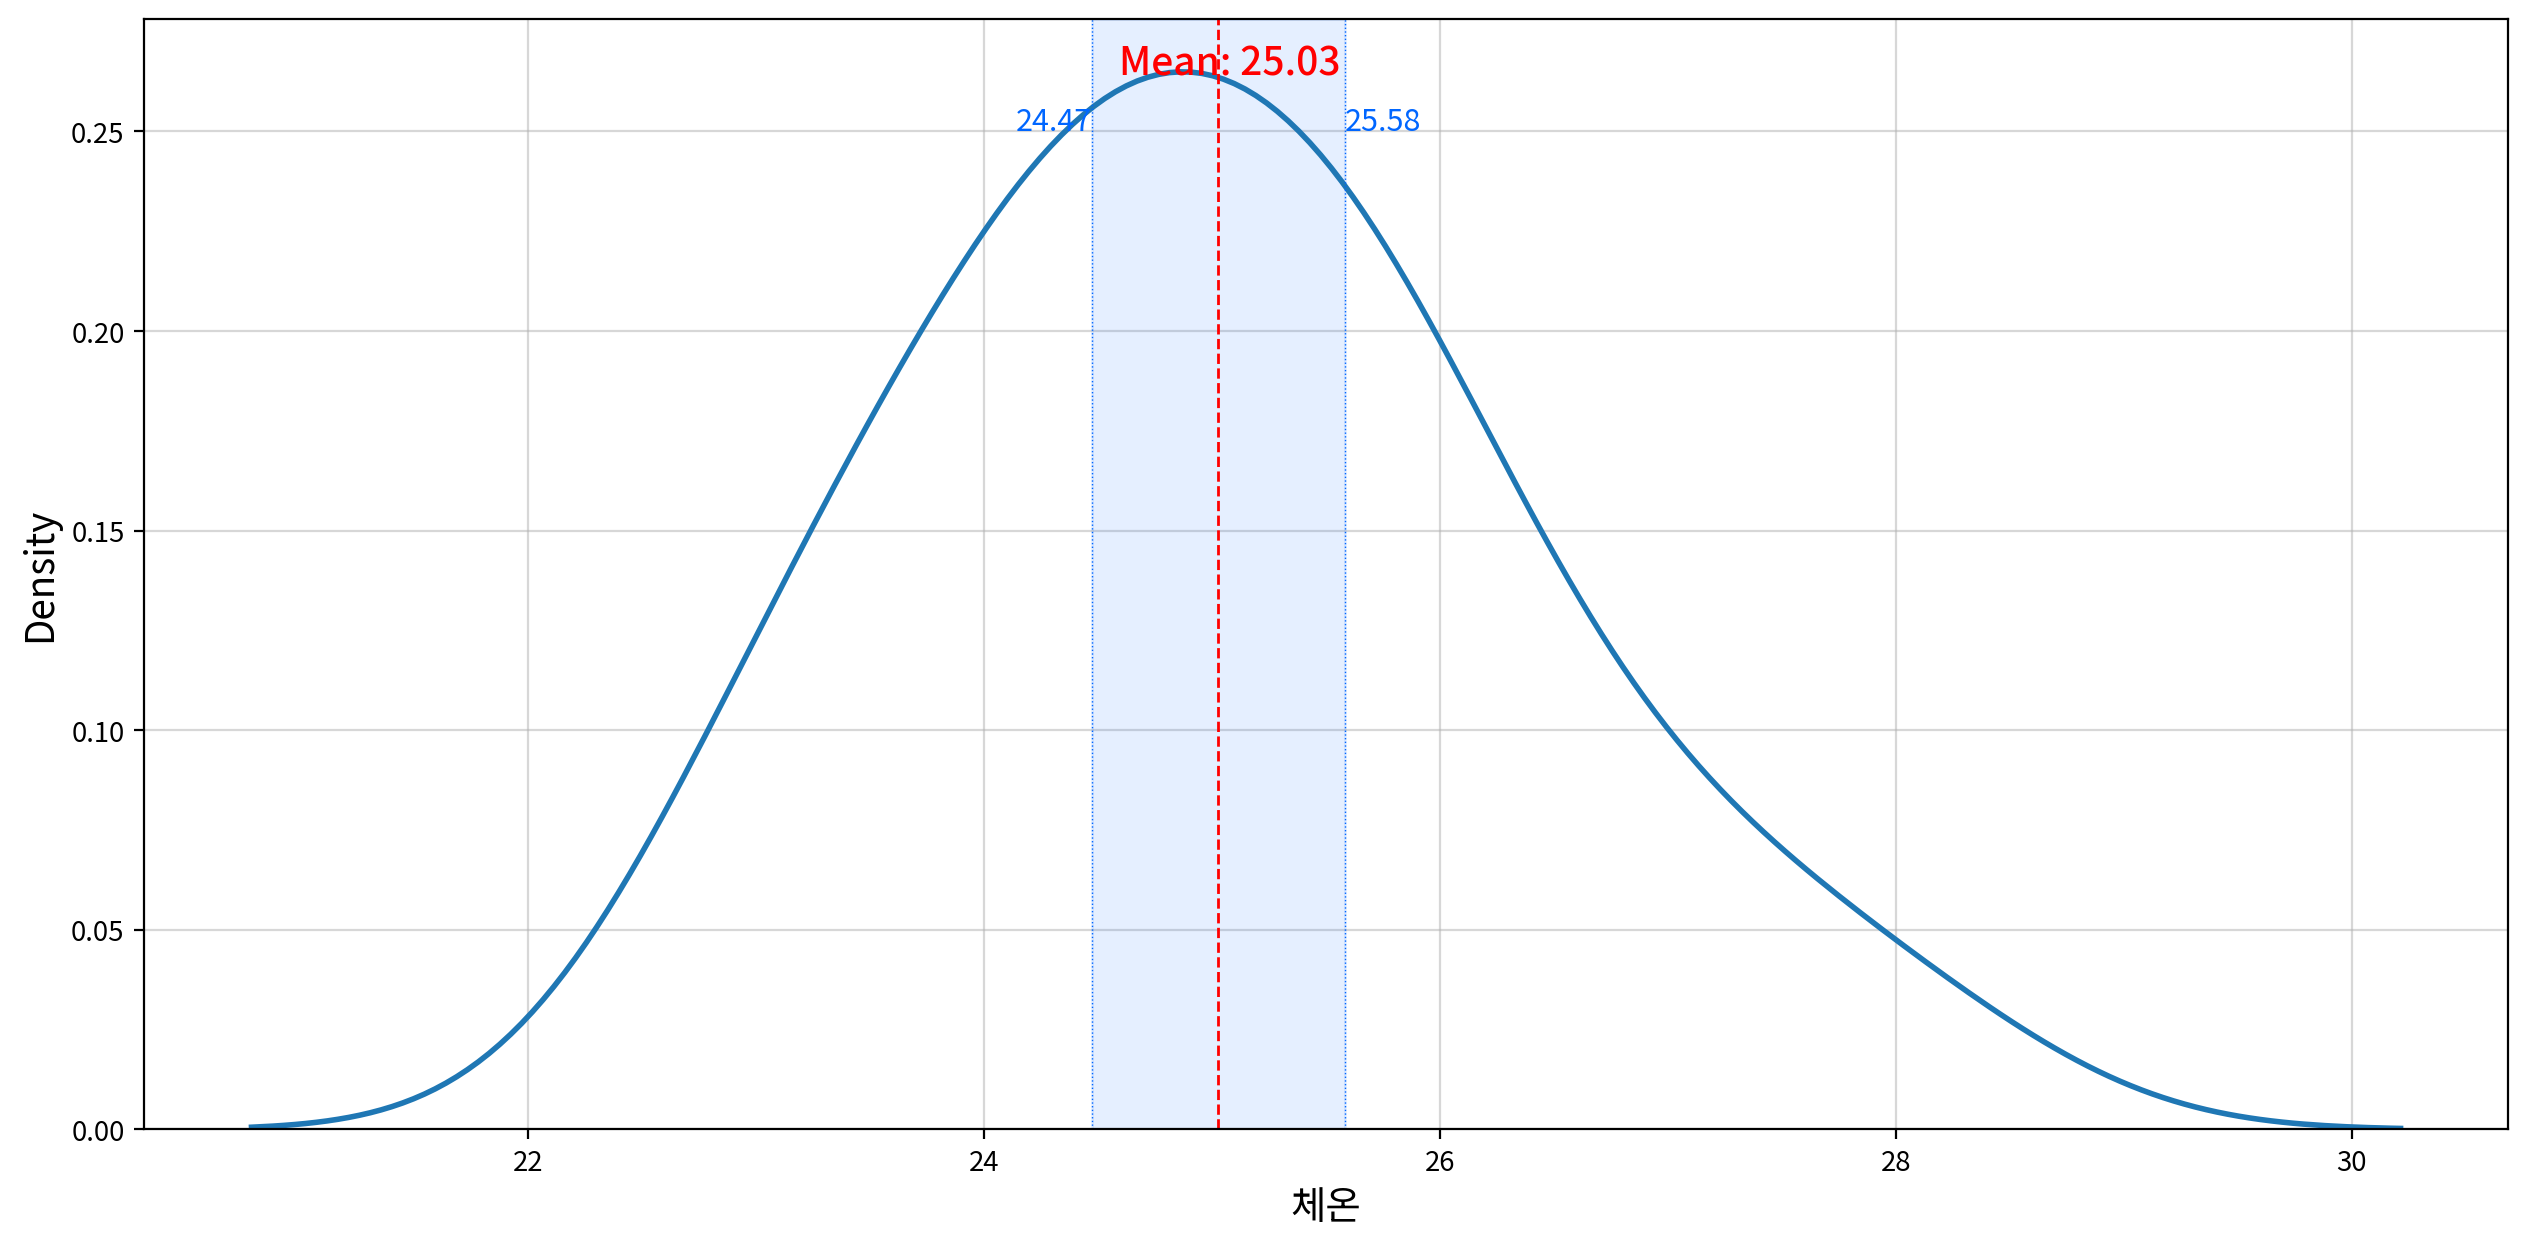

In [19]:
my_plot.kdeplot(df1, x='체온', meanline=True, clevel=0.95)

- 인사이트
    - 커널밀도 함수 그래프의 모양이 정규분포를 듸고 있으며, 표본평균(25.03)이 신뢰구간(24.47~25.58)에 포함되어 있으므로, 강아지의 체온이 정상범위에 있다고 할 수 있다.
    - 시각화 결과로 정규성 가정을 충족하는 것 같지만 정확한 통계량으로 정규성 충족 여부를 확인하기 위해 NormalTest를 수행한다.

### 3. 가설검정의 가정 확인
- helpers패키지의 test_assumptions 함수는 NormalTest를 통해 정규성 검정 결과를 반환한다.

In [20]:
my_stats.test_assumptions(df1, columns=['체온'])

,test,statistic,p-value,result
field,,,,
체온,normaltest,0.819,0.664,True


- p-value가 0.0664이므로 (p >=0.05)정규성을 충족하므로 One Sample T-Test를 수행함

### 4. One Sample T-Test > 양측검정
- 강아지의 평균 체온이 과거의 자료인 24.3과 달라졌는지 여부
- alternative 파라미터는 two-side가 기본값이므로 양측검정의 경우 생략 가능

In [21]:
popmean = 24.3           # 비교값을 변수로 저장
alternative = "two-sided" # 'two-sided', 'less', 'greater'
s, p = ttest_1samp(df1['체온'], popmean, alternative=alternative)
print(f"t-statistic: {s:.4f}, p-value: {p:.4f}")

t-statistic: 2.7128, p-value: 0.0121


- 단일표본 t-검정 결과, t-값은 2.713, p-value는 0.012로 나타났다.
따라서 귀무가설을 기각하고 대립가설을 채택한다(p < 0.05)
이는 모집단의 평균(24.3)과 표본평균 사이에 유의한 차이가 있음을 의미한다.

### 5. One Sample T-Test > 좌측 단측 검정
- 강아지의 평균 체온이 과거의 자료인 24.3보다 작아졌는지 알고자 하는 경우 
- alternative 파라미터에 less를 설정

In [22]:
popmean = 24.3           # 비교값을 변수로 저장
alternative = "less" # 'two-sided', 'less', 'greater'
s, p = ttest_1samp(df1['체온'], popmean, alternative=alternative)
print(f"t-statistic: {s:.4f}, p-value: {p:.4f}")

t-statistic: 2.7128, p-value: 0.9939


- 단일표본 t-검정 결과, t-값은 2.713, p-value는 0.994로 나타났다.
p-value가 0.05보다 크르모 귀무가설을 기각할 수 없다(p>=0.05)
즉, 강아지의 평균 체온은 24.3보다 작지 않다.

### 6. One Sample T-Test > 우측 단측 검정
- 강아지의 평균 체온이 과거의 자료인 24.3보다 커졌는지 알고자 하는 경우 
- alternative 파라미터에 greater를 설정

In [23]:
popmean = 24.3           # 비교값을 변수로 저장
alternative = "greater" # 'two-sided', 'less', 'greater'
s, p = ttest_1samp(df1['체온'], popmean, alternative=alternative)
print(f"t-statistic: {s:.4f}, p-value: {p:.4f}")

t-statistic: 2.7128, p-value: 0.0061


- 단일표본 t-검정 결과, t-값은 2.713, p-value는 0.006으로 나타났다.
p-value가 0.05보다 작으므로 귀무가설을 기각하고 대립가설을 채택한다.(p<0.05)
즉, 강아지의 평균 체온은 24.3보다 크다.

## #03.예제(2)- 생명보험 가입금액 평균 비교
### 1. 데이터 가져오기
- insur 데이터는 어느 보험회사에서 한해 동안 모집한 가입원들에 대한 가입정보임
    - 이 회사에서 올해 실적을 가입원들의 평균 가입 금액이 1억원인 것을 목표로 삼았을 때 이 회사는 목표 실적을 달성했다고 볼 수 있는지 검정하라

In [24]:
df2= load_data('insur')
df2.head()

📚 어느 보험회사에서 한해 동안 모집한 가입원들에 대한 가입 정보 (출처: 방송통신대학교 통계학개론)

    field     description
--  --------  ------------------------------------------------------
 0  직업      1=육체노동, 2=정신노동(직상인), 3=자영업
 1  교육수준  1=초등학교 이하, 2=중졸 및 고졸, 3=대졸, 4=대학원 졸업
 2  성별      1=남자, 2=여자
 3  나이      숫자
 4  가입금액  단위=천만원
 5  월수입    단위=만원



,직업,교육수준,성별,나이,가입금액,월수입
0,1,2,1,35,15.000,100
1,2,3,1,40,10.000,150
2,2,3,2,36,8.000,120
3,3,4,2,38,12.000,140
4,1,1,1,45,10.000,150


### 2. 데이터 분포 시각화

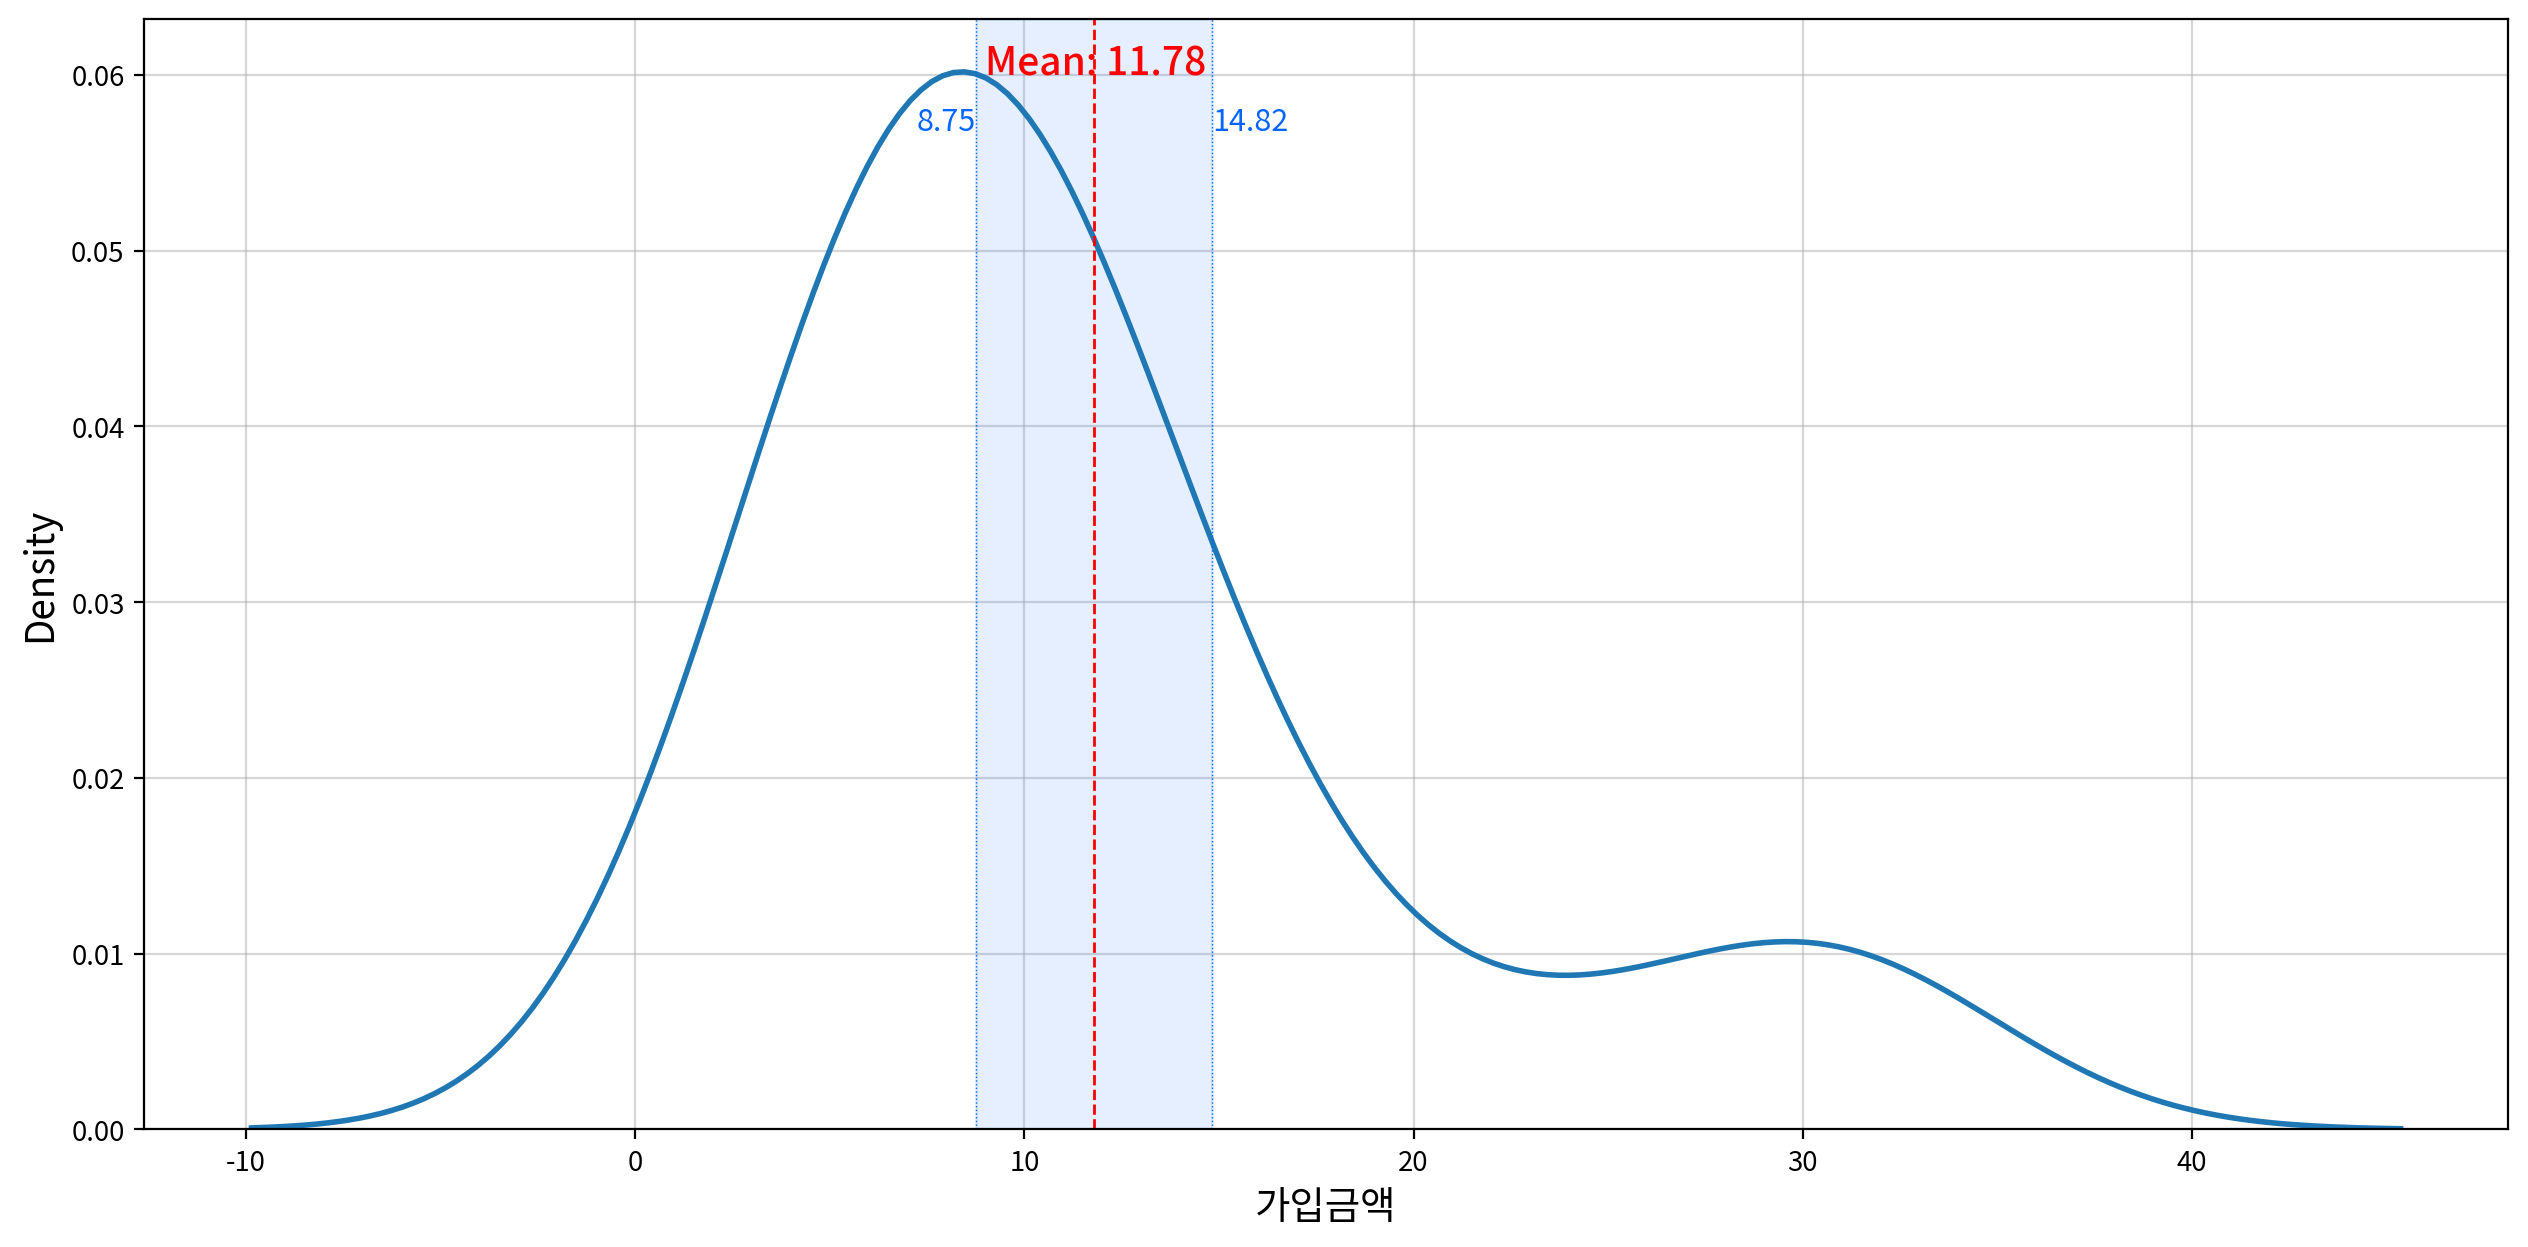

In [25]:
my_plot.kdeplot(df2, x='가입금액', meanline=True, clevel=0.95)

- 인사이트
    - 표본평균(11.8)이 신뢰구간(8.75~14.82)에 포함되어 있으므로 가입금액의 데이터는 정상범위에 있다고 할 수 있지만, 거널밀도 함수 그래프의 모양을 보았을 때 정규분포를 만족하지는 않고 있다.

### 3. 데이터의 정규성 검정

In [26]:
my_stats.test_assumptions(df2, columns='가입금액')

,test,statistic,p-value,result
field,,,,
가입금액,normaltest,11.438,0.003,False


- 주어진 데이터는 p-value가 0.003이므로 정규성을 충족하지 않는다(p<0.05)
One Sample T-Test를 사용하지 않고 Willcoxon Signed Rank Test를 수행해야 함

### 4. Willcoxon Signed Rank Test - 양측검정
- 가입금액의 평균이 1억원과 같은지, 다른지 여부

In [27]:
# 천만원 단위에서 1억원
target_value = 10.0

# 기준값을 뺀 차이에 대한 Wilcoxon 부호 순위 검정
s, p =wilcoxon(df2['가입금액'] - target_value)
print(f'Wilcoxon statistic: {s:.4f}, p-value: {p:.4f}')

Wilcoxon statistic: 183.5000, p-value: 0.8948


- Willcoxon Signed Rank Test 결과 보험 가입금액의 모평균이 1억원이라는 귀무가설을 기갈할 수 없다.(p>=0.05)
즉, 보험 가입금액의 평균은 1억원이다. 

### 5. Willcoxon Signed Rank Test - 좌측 단측검정

In [28]:
s, p =wilcoxon(df2['가입금액'] - target_value, alternative='less')
print(f'Wilcoxon statistic: {s:.4f}, p-value: {p:.4f}')

Wilcoxon statistic: 194.5000, p-value: 0.5526


- Willcoxon Signed Rank Test를 통한 좌측 단측검정 결과 보험 가입금액의 모평균이 1억원보다 작지 않다는 귀무가설을 기각할 수 없다(p>=0.05)

### 6. Willcoxon Signed Rank Test - 우측 단측검정
- 가입금액의 평균이 1억원보다 큰지 여부

In [29]:
s, p =wilcoxon(df2['가입금액'] - target_value, alternative='greater')
print(f'Wilcoxon statistic: {s:.4f}, p-value: {p:.4f}')

Wilcoxon statistic: 194.5000, p-value: 0.4474


- Willcoxon Signed Rank Test를 통한 우측 단측검정 결과 보험 가입금액의 모평균이 1억원보다 크지 않다는 귀무가설을 기각할 수 없다(p>=0.05)

## #04. 모듈 기능 확인
### 1. 강아지 체온 변화

In [30]:
my_stats.test_1sample(df1, column='체온', popmean=24.3)

statistic  p-value  significant  result
test              alternative                                         
One-sample t-test two-sided        2.713    0.012         True   차이 있음
                  less             2.713    0.994        False    차이없음
                  greater          2.713    0.006         True  μ₀보다 큼

### 2. 생명보험 가입 평균 금액 비교

In [31]:
my_stats.test_1sample(df2, column='가입금액', popmean=10)

statistic  p-value  significant result
test                      alternative                                        
Wilcoxon signed-rank test two-sided      183.500    0.895        False   차이없음
                          less           194.500    0.553        False   차이없음
                          greater        194.500    0.447        False   차이없음